# Kiểm thử 2 — Robustness
**DS200.F21.CN2 — AI Face Detection**

Đánh giá độ bền của model dưới JPEG compression, resize, và Gaussian blur.

> **Cách chạy:** Bấm **Run All** (▶▶) — không cần thay đổi gì thêm.
> Thời gian ước tính: **10–15 phút** với GPU T4.

In [2]:
# ── Cài thư viện nếu cần ───────────────────────────────
import subprocess
subprocess.run(["pip", "install", "timm", "albumentations", "--upgrade", "-q"],
               capture_output=True)

import os, json, io, pandas as pd, numpy as np
import torch, torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from PIL import Image, ImageFilter
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from tqdm import tqdm

# ── Reproducibility ────────────────────────────────────
import random
random.seed(42); np.random.seed(42); torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# ── Config ─────────────────────────────────────────────
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_PATH = "/kaggle/input/datasets/thanhlongtrn/ds200-checkpoint/best_stage3.pth"
TEST_CSV        = "/kaggle/input/datasets/thanhlongtrn/ds200-checkpoint/test.csv"
BATCH_SIZE      = 64
OUTPUT_DIR      = "/kaggle/working/robustness"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Mapping path local → path Kaggle ───────────────────
DATASET_PATH_MAP = {
    "140k-real-and-fake-faces":     "/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/",
    "deepfake-and-real-images":     "/kaggle/input/datasets/manjilkarki/deepfake-and-real-images",
    "hardfakevsrealfaces":          "/kaggle/input/datasets/hamzaboulahia/hardfakevsrealfaces",
    "real-and-fake-face-detection": "/kaggle/input/datasets/ciplab/real-and-fake-face-detection",
}

def remap_path(local_path: str) -> str:
    for key, kaggle_root in DATASET_PATH_MAP.items():
        if key in local_path:
            suffix = local_path[local_path.index(key) + len(key):]
            return kaggle_root + suffix
    return local_path

print(f"Device : {DEVICE}")
print(f"torch  : {torch.__version__}")
print(f"timm   : {timm.__version__}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")


Device : cuda
torch  : 2.10.0+cu128
timm   : 1.0.27
GPU    : Tesla T4


## Định nghĩa Model & Transform

In [3]:
# ── Định nghĩa Model ───────────────────────────────────

class FaceDetector(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            "efficientnet_b0", pretrained=False, num_classes=0
        )
        self.classifier = nn.Sequential(
            nn.Linear(1280, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1),
        )
    def forward(self, x):
        return self.classifier(self.backbone(x))  # ← sửa head → classifier


def load_model(checkpoint_path: str, device) -> FaceDetector:
    model = FaceDetector().to(device)
    ckpt  = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"Loaded checkpoint — epoch {ckpt['epoch']}, val_loss {ckpt['val_loss']:.4f}")
    model.eval()
    return model


cfg           = timm.create_model("efficientnet_b0", pretrained=False).default_cfg
MEAN, STD     = list(cfg["mean"]), list(cfg["std"])
val_transform = A.Compose([
    A.LongestMaxSize(max_size=224),
    A.PadIfNeeded(224, 224, border_mode=0),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

print("Model và transform đã sẵn sàng.")


Model và transform đã sẵn sàng.


## Perturbation Functions

| Tên | Mô tả |
|-----|-------|
| `baseline` | Không biến đổi |
| `jpeg_q70/50/30` | Nén JPEG quality 70, 50, 30 |
| `resize_50/25` | Thu nhỏ 50%, 25% rồi phóng lại |
| `blur_s1/s2` | Gaussian blur σ=1.0, σ=2.0 |

In [4]:
# ── Perturbation functions ─────────────────────────────

def apply_jpeg_compression(img_pil: Image.Image, quality: int) -> Image.Image:
    buf = io.BytesIO()
    img_pil.save(buf, format="JPEG", quality=quality)
    buf.seek(0)
    return Image.open(buf).convert("RGB")

def apply_resize_downup(img_pil: Image.Image, scale: float) -> Image.Image:
    w, h    = img_pil.size
    small_w = max(1, int(w * scale))
    small_h = max(1, int(h * scale))
    small   = img_pil.resize((small_w, small_h), Image.BILINEAR)
    return small.resize((w, h), Image.BILINEAR)

def apply_gaussian_blur(img_pil: Image.Image, sigma: float) -> Image.Image:
    return img_pil.filter(ImageFilter.GaussianBlur(radius=sigma))

PERTURBATIONS = {
    "baseline":  lambda img: img,
    "jpeg_q70":  lambda img: apply_jpeg_compression(img, 70),
    "jpeg_q50":  lambda img: apply_jpeg_compression(img, 50),
    "jpeg_q30":  lambda img: apply_jpeg_compression(img, 30),
    "resize_50": lambda img: apply_resize_downup(img, 0.50),
    "resize_25": lambda img: apply_resize_downup(img, 0.25),
    "blur_s1":   lambda img: apply_gaussian_blur(img, 1.0),
    "blur_s2":   lambda img: apply_gaussian_blur(img, 2.0),
}

print(f"Đã định nghĩa {len(PERTURBATIONS)} perturbation.")


Đã định nghĩa 8 perturbation.


## Dataset với Perturbation

In [5]:
# ── Dataset với perturbation ───────────────────────────

class RobustnessDataset(Dataset):
    def __init__(self, df: pd.DataFrame, perturb_fn, transform):
        self.df         = df.reset_index(drop=True)
        self.perturb_fn = perturb_fn
        self.transform  = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        img    = Image.open(row["image_path"]).convert("RGB")
        img    = self.perturb_fn(img)
        img_np = np.array(img)
        img_t  = self.transform(image=img_np)["image"]
        label  = torch.tensor(row["label"], dtype=torch.float32)
        return img_t, label


## Load Model & Test Set

In [6]:
model   = load_model(CHECKPOINT_PATH, DEVICE)
test_df = pd.read_csv(TEST_CSV)

# ── Fix 1: chuyển backslash → forward slash ────────────
test_df["image_path"] = test_df["image_path"].str.replace("\\", "/", regex=False)

# ── Fix 2: remap path local → Kaggle ──────────────────
test_df["image_path"] = test_df["image_path"].apply(remap_path)

# ── Fix 3: chuyển label string → int (Real=0, Fake=1) ─
if test_df["label"].dtype == object:
    test_df["label"] = test_df["label"].map({"Real": 0, "Fake": 1})
    print("Đã chuyển label string → int  (Real=0, Fake=1)")

print(test_df["label"].value_counts())
# ── Kiểm tra 3 đường dẫn đầu để xác nhận đúng ─────────
print(test_df["image_path"].head(3).to_string())

# ── Kiểm tra file đầu tiên có tồn tại không ───────────
import os
first = test_df["image_path"].iloc[0]
print(f"\nFile tồn tại: {os.path.exists(first)}")

Loaded checkpoint — epoch 30, val_loss 0.0699
Đã chuyển label string → int  (Real=0, Fake=1)
label
1    25019
0    22461
Name: count, dtype: int64
0    /kaggle/input/datasets/xhlulu/140k-real-and-fa...
1    /kaggle/input/datasets/xhlulu/140k-real-and-fa...
2    /kaggle/input/datasets/manjilkarki/deepfake-an...

File tồn tại: True


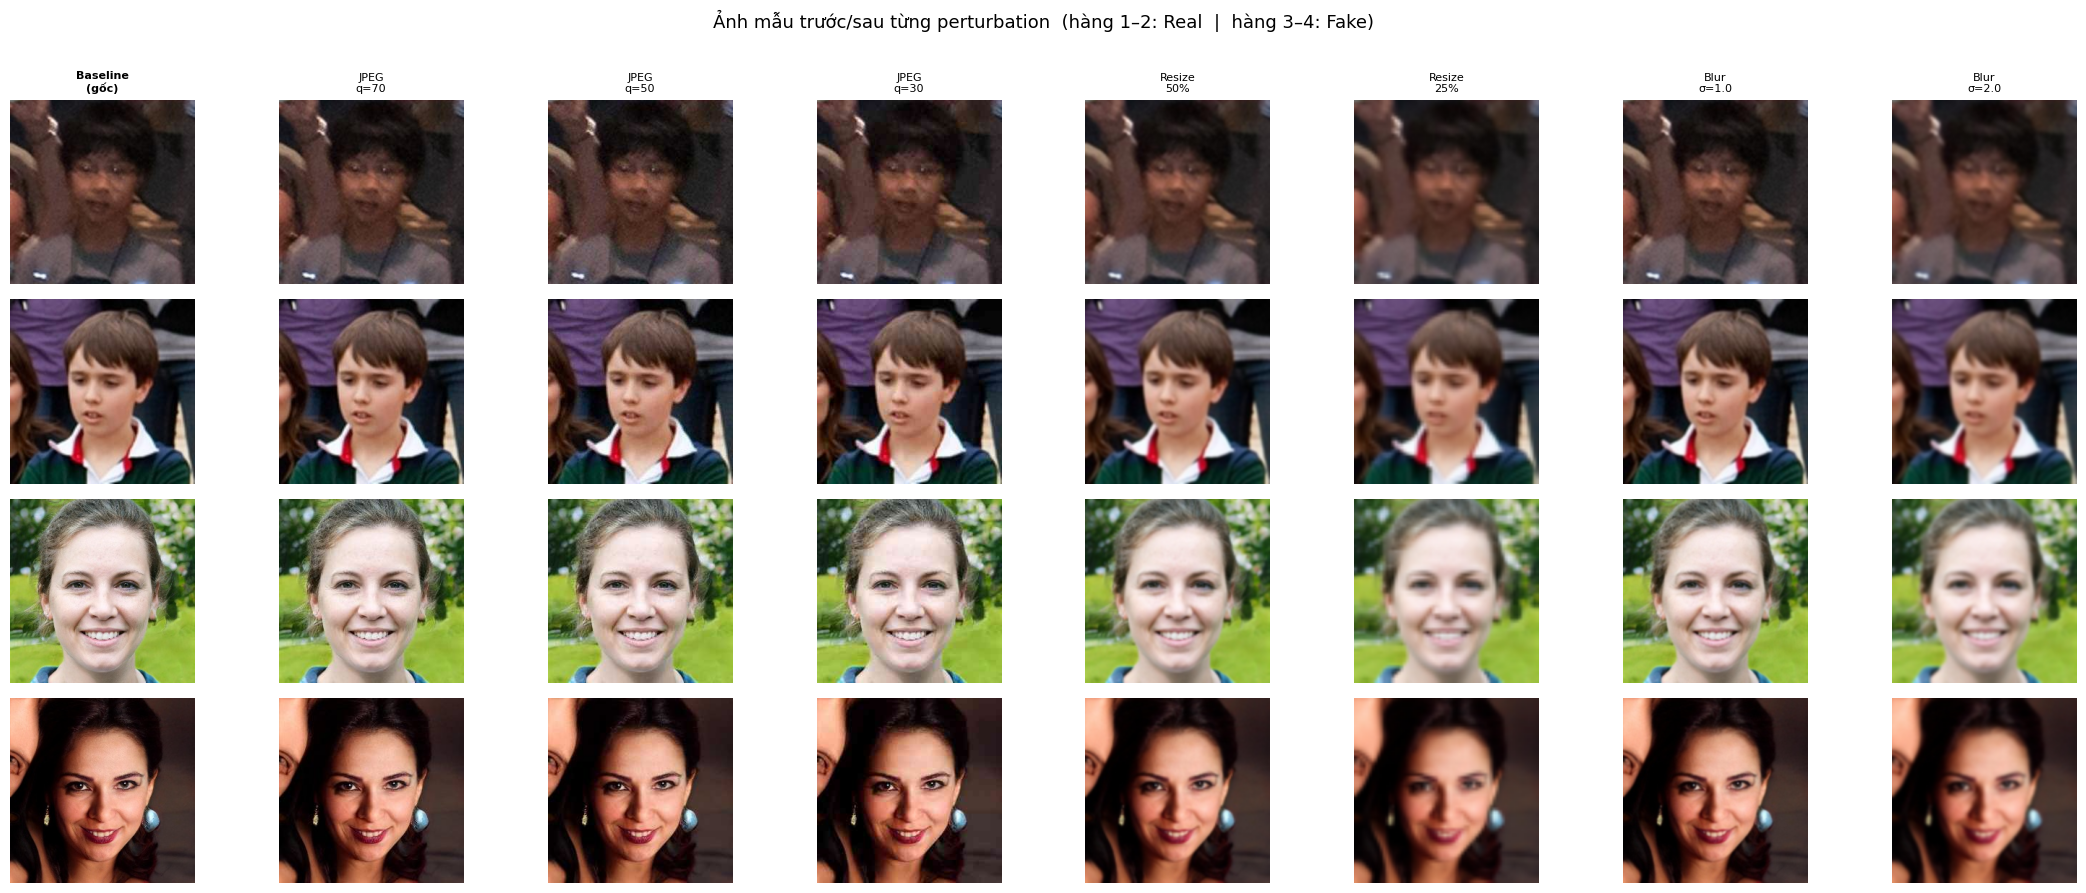

In [7]:
# ── Visualization ảnh mẫu trước/sau perturbation ────────
import io as _io, random as _random
from IPython.display import Image as IPImage, display as ipy_display

N_SAMPLES = 2  # số mẫu mỗi lớp

_random.seed(42)
_real_paths = _random.sample(
    test_df[test_df["label"] == 0]["image_path"].tolist(), N_SAMPLES
)
_fake_paths = _random.sample(
    test_df[test_df["label"] == 1]["image_path"].tolist(), N_SAMPLES
)

_perturb_order = ["baseline", "jpeg_q70", "jpeg_q50", "jpeg_q30",
                  "resize_50", "resize_25", "blur_s1", "blur_s2"]
_col_labels = {
    "baseline":  "Baseline\n(gốc)",
    "jpeg_q70":  "JPEG\nq=70",
    "jpeg_q50":  "JPEG\nq=50",
    "jpeg_q30":  "JPEG\nq=30",
    "resize_50": "Resize\n50%",
    "resize_25": "Resize\n25%",
    "blur_s1":   "Blur\nσ=1.0",
    "blur_s2":   "Blur\nσ=2.0",
}

# 5 Real + 5 Fake → 10 hàng × 8 cột
all_samples = [("Real", p) for p in _real_paths] + [("Fake", p) for p in _fake_paths]
n_rows = len(all_samples)

fig, axes = plt.subplots(n_rows, 8, figsize=(22, n_rows * 2.2))
for row_idx, (row_label, path) in enumerate(all_samples):
    try:
        img = Image.open(path).convert("RGB")
    except Exception:
        img = Image.fromarray(np.zeros((224, 224, 3), dtype=np.uint8))
    for col_idx, name in enumerate(_perturb_order):
        perturbed = PERTURBATIONS[name](img.copy())
        ax = axes[row_idx][col_idx]
        ax.imshow(perturbed)
        ax.axis("off")
        # Tiêu đề cột chỉ ở hàng đầu tiên
        if row_idx == 0:
            ax.set_title(_col_labels[name], fontsize=8,
                         fontweight="bold" if name == "baseline" else "normal")
        # Nhãn hàng ở cột đầu tiên
        if col_idx == 0:
            sample_num = (row_idx % N_SAMPLES) + 1
            ax.set_ylabel(f"{row_label} {sample_num}", fontsize=9,
                          fontweight="bold", rotation=0, labelpad=42, va="center")
    # Đường kẻ ngăn cách Real / Fake
    if row_idx == N_SAMPLES - 1:
        for col_idx in range(8):
            axes[row_idx][col_idx].spines["bottom"].set_visible(True)
            axes[row_idx][col_idx].spines["bottom"].set_linewidth(1.5)
            axes[row_idx][col_idx].spines["bottom"].set_color("#888")

fig.suptitle(
    f"Ảnh mẫu trước/sau từng perturbation  "
    f"(hàng 1–{N_SAMPLES}: Real  |  hàng {N_SAMPLES+1}–{2*N_SAMPLES}: Fake)",
    fontsize=13, y=1.01
)
plt.tight_layout()
buf = _io.BytesIO()
fig.savefig(buf, format="png", dpi=100, bbox_inches="tight")
buf.seek(0)
plt.close(fig)
ipy_display(IPImage(data=buf.getvalue()))

## Chạy Đánh giá

> 8 perturbation × toàn bộ test set — ước tính 10–15 phút trên GPU T4.

In [8]:
# ── Chạy đánh giá 8 perturbation ──────────────────────
# Mỗi perturbation chạy toàn bộ test set — ước tính 10–15 phút trên GPU T4

robustness_results = {}

for name, perturb_fn in PERTURBATIONS.items():
    print(f"\n[{name}] đang đánh giá...", flush=True)
    dataset = RobustnessDataset(test_df, perturb_fn, val_transform)
    loader  = DataLoader(dataset, batch_size=BATCH_SIZE,
                         num_workers=2, pin_memory=True)

    all_preds, all_probs, all_labels = [], [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc=name, leave=False):
            logits = model(imgs.to(DEVICE)).squeeze(1)
            probs  = torch.sigmoid(logits).cpu().numpy()
            preds  = (probs >= 0.5).astype(int)
            all_probs.extend(probs.tolist())
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.numpy().tolist())

    y, p, prob = np.array(all_labels), np.array(all_preds), np.array(all_probs)
    robustness_results[name] = {
        "accuracy":  float(accuracy_score(y, p)),
        "precision": float(precision_score(y, p, zero_division=0)),
        "recall":    float(recall_score(y, p, zero_division=0)),
        "f1":        float(f1_score(y, p, zero_division=0)),
        "auc":       float(roc_auc_score(y, prob)),
    }
    m = robustness_results[name]
    print(f"  Accuracy={m['accuracy']:.4f}  Precision={m['precision']:.4f}  "
          f"Recall={m['recall']:.4f}  F1={m['f1']:.4f}  AUC={m['auc']:.4f}")

print("\n✓ Hoàn thành đánh giá tất cả perturbation.")



[baseline] đang đánh giá...


  Accuracy=0.9733  Precision=0.9773  Recall=0.9719  F1=0.9746  AUC=0.9970

[jpeg_q70] đang đánh giá...


  Accuracy=0.8233  Precision=0.7588  Recall=0.9744  F1=0.8532  AUC=0.9597

[jpeg_q50] đang đánh giá...


  Accuracy=0.7977  Precision=0.7334  Recall=0.9679  F1=0.8345  AUC=0.9330

[jpeg_q30] đang đánh giá...


  Accuracy=0.7860  Precision=0.7254  Recall=0.9558  F1=0.8248  AUC=0.9030

[resize_50] đang đánh giá...


  Accuracy=0.8539  Precision=0.8906  Recall=0.8239  F1=0.8560  AUC=0.9358

[resize_25] đang đánh giá...


  Accuracy=0.7287  Precision=0.7144  Recall=0.8085  F1=0.7585  AUC=0.8040

[blur_s1] đang đánh giá...


  Accuracy=0.9045  Precision=0.9724  Recall=0.8427  F1=0.9029  AUC=0.9776

[blur_s2] đang đánh giá...


  Accuracy=0.7365  Precision=0.7744  Recall=0.7056  F1=0.7384  AUC=0.8211

✓ Hoàn thành đánh giá tất cả perturbation.


In [9]:
# ── Hiển thị bảng kết quả đầy đủ ──────────────────────
import pandas as pd
from IPython.display import display

ORDER = ["baseline","jpeg_q70","jpeg_q50","jpeg_q30",
         "resize_50","resize_25","blur_s1","blur_s2"]

base_acc = robustness_results["baseline"]["accuracy"]

rows = []
for name in ORDER:
    if name not in robustness_results:
        continue
    m = robustness_results[name]
    rows.append({
        "Perturbation": name,
        "Accuracy":     round(m["accuracy"],  4),
        "Precision":    round(m["precision"], 4),
        "Recall":       round(m["recall"],    4),
        "F1":           round(m["f1"],        4),
        "AUC-ROC":      round(m["auc"],       4),
        "Drop Acc":     round(base_acc - m["accuracy"], 4),
    })

df_results = pd.DataFrame(rows).set_index("Perturbation")

def _color_drop(val):
    if val <= 0.02:
        return "background-color: #ccffcc"
    elif val <= 0.05:
        return "background-color: #fff3cc"
    else:
        return "background-color: #ffcccc"

styled = (df_results.style
    .applymap(_color_drop, subset=["Drop Acc"])
    .format("{:.4f}")
    .set_caption("Kết quả đánh giá Robustness — 5 metric theo từng perturbation"))
display(styled)


/tmp/ipykernel_58/2645250062.py:36: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(_color_drop, subset=["Drop Acc"])


,Accuracy,Precision,Recall,F1,AUC-ROC,Drop Acc
Perturbation,,,,,,
baseline,0.9733,0.9773,0.9719,0.9746,0.9970,0.0000
jpeg_q70,0.8233,0.7588,0.9744,0.8532,0.9597,0.1500
jpeg_q50,0.7977,0.7334,0.9679,0.8345,0.9330,0.1756
jpeg_q30,0.7860,0.7254,0.9558,0.8248,0.9030,0.1873
resize_50,0.8539,0.8906,0.8239,0.8560,0.9358,0.1194
resize_25,0.7287,0.7144,0.8085,0.7585,0.8040,0.2446
blur_s1,0.9045,0.9724,0.8427,0.9029,0.9776,0.0688
blur_s2,0.7365,0.7744,0.7056,0.7384,0.8211,0.2368


## Phân tích kết quả Robustness

Bảng kết quả đầy đủ (Accuracy / Precision / Recall / F1 / AUC-ROC / Drop Acc) được hiển thị tự động trong cell code ngay trên đây sau khi chạy. Các biểu đồ chi tiết ở phần bên dưới.

**Màu sắc ô Drop Acc:** 🟢 xanh ≤ 2 pp | 🟡 vàng ≤ 5 pp | 🔴 đỏ > 5 pp (cần cải thiện)


Saved robustness_metrics.json


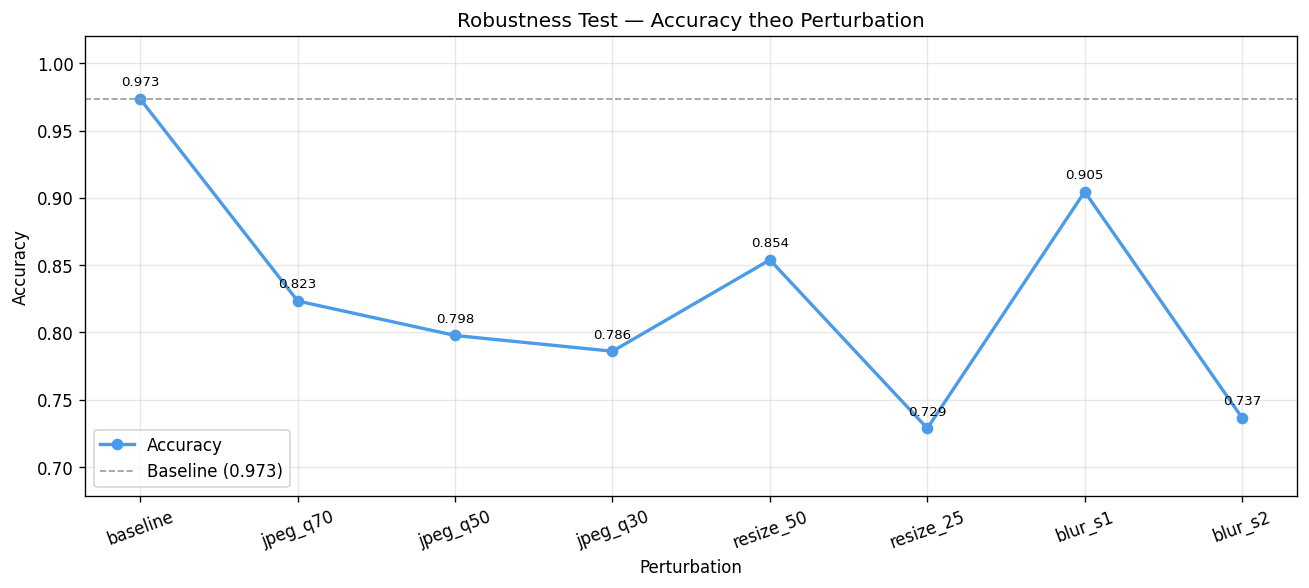

Saved robustness_accuracy.png


In [10]:
# ── Lưu kết quả & vẽ biểu đồ ──────────────────────────
import io as _io
from IPython.display import Image as IPImage, display as ipy_display

# 1. Lưu JSON
with open(f"{OUTPUT_DIR}/robustness_metrics.json", "w") as f:
    json.dump(robustness_results, f, indent=2)
print("Saved robustness_metrics.json")

# 2. Chuẩn bị dữ liệu chung
ORDER     = ["baseline","jpeg_q70","jpeg_q50","jpeg_q30",
             "resize_50","resize_25","blur_s1","blur_s2"]
names     = [n for n in ORDER if n in robustness_results]
acc_vals  = [robustness_results[n]["accuracy"]  for n in names]
prec_vals = [robustness_results[n]["precision"] for n in names]
rec_vals  = [robustness_results[n]["recall"]    for n in names]
f1_vals   = [robustness_results[n]["f1"]        for n in names]
auc_vals  = [robustness_results[n]["auc"]       for n in names]
base_acc  = robustness_results["baseline"]["accuracy"]
base_auc  = robustness_results["baseline"]["auc"]

def _save_and_show(fig, path):
    fig.savefig(path, dpi=150, bbox_inches="tight")
    buf = _io.BytesIO()
    fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
    buf.seek(0)
    plt.close(fig)
    ipy_display(IPImage(data=buf.getvalue()))

# 3. Biểu đồ 1: Line chart Accuracy
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(names, acc_vals, marker="o", linewidth=2, color="#4C9BE8", label="Accuracy")
ax.axhline(base_acc, linestyle="--", color="#999", linewidth=1,
           label=f"Baseline ({base_acc:.3f})")
for n, v in zip(names, acc_vals):
    ax.annotate(f"{v:.3f}", (n, v), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8)
ax.set_ylim(max(0, min(acc_vals) - 0.05), 1.02)
ax.set_xlabel("Perturbation"); ax.set_ylabel("Accuracy")
ax.set_title("Robustness Test — Accuracy theo Perturbation")
ax.legend(); ax.tick_params(axis="x", rotation=20)
ax.grid(True, alpha=0.3)
fig.tight_layout()
_save_and_show(fig, f"{OUTPUT_DIR}/robustness_accuracy.png")
print("Saved robustness_accuracy.png")


### Nhận xét — Biểu đồ 1: Accuracy theo Perturbation

- **Blur σ=1.0** ít bị ảnh hưởng nhất (Accuracy 0.9045, Drop −6.9 pp) — blur nhẹ chỉ làm mờ cạnh, nhiều đặc trưng GAN vẫn còn nhận diện được
- **JPEG** sụt giảm tỷ lệ thuận với độ nén: q=70 (−15.0 pp) → q=50 (−17.6 pp) → q=30 (−18.7 pp); nén JPEG xóa artifact tần số cao — đây là đặc trưng chính mô hình dựa vào để phân biệt fake
- **Resize 25%** gây Drop −24.5 pp (lớn nhất về Accuracy) — micro-texture biến mất gần hoàn toàn sau downscale 75%
- **Blur σ=2.0** gần bằng Resize 25% (Drop −23.7 pp) — mức blur mạnh phá hủy phần lớn fine-grained detail

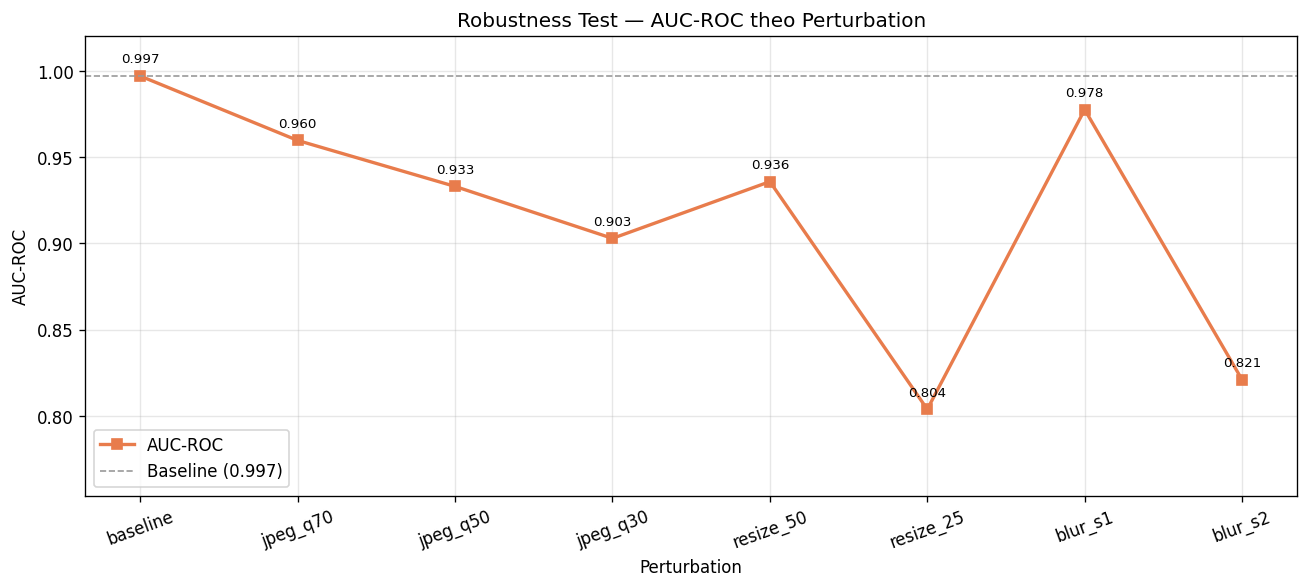

Saved robustness_auc.png


In [11]:
# Biểu đồ 2: Line chart AUC-ROC
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(names, auc_vals, marker="s", linewidth=2, color="#E87C4C", label="AUC-ROC")
ax.axhline(base_auc, linestyle="--", color="#999", linewidth=1,
           label=f"Baseline ({base_auc:.3f})")
for n, v in zip(names, auc_vals):
    ax.annotate(f"{v:.3f}", (n, v), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8)
ax.set_ylim(max(0, min(auc_vals) - 0.05), 1.02)
ax.set_xlabel("Perturbation"); ax.set_ylabel("AUC-ROC")
ax.set_title("Robustness Test — AUC-ROC theo Perturbation")
ax.legend(); ax.tick_params(axis="x", rotation=20)
ax.grid(True, alpha=0.3)
fig.tight_layout()
_save_and_show(fig, f"{OUTPUT_DIR}/robustness_auc.png")
print("Saved robustness_auc.png")

### Nhận xét — Biểu đồ 2: AUC-ROC theo Perturbation

- **AUC giảm chậm hơn Accuracy** ở nhiễu nhẹ — mô hình vẫn xếp hạng real/fake tương đối tốt kể cả khi artifact bị nhiễu một phần
- **JPEG q=70**: AUC=0.960 dù Accuracy chỉ 0.823 → ngưỡng quyết định 0.5 không còn tối ưu; có thể điều chỉnh threshold để cải thiện kết quả thực tế
- **Resize 25%** kéo AUC xuống 0.804 — thấp nhất toàn bộ; ngay cả khả năng xếp hạng cũng bị phá vỡ khi mất quá nhiều texture
- **Blur σ=1 → σ=2** tạo khoảng cách AUC lớn (0.978 → 0.821, chênh 15.7 pp) — mô hình cực nhạy với mức độ blur

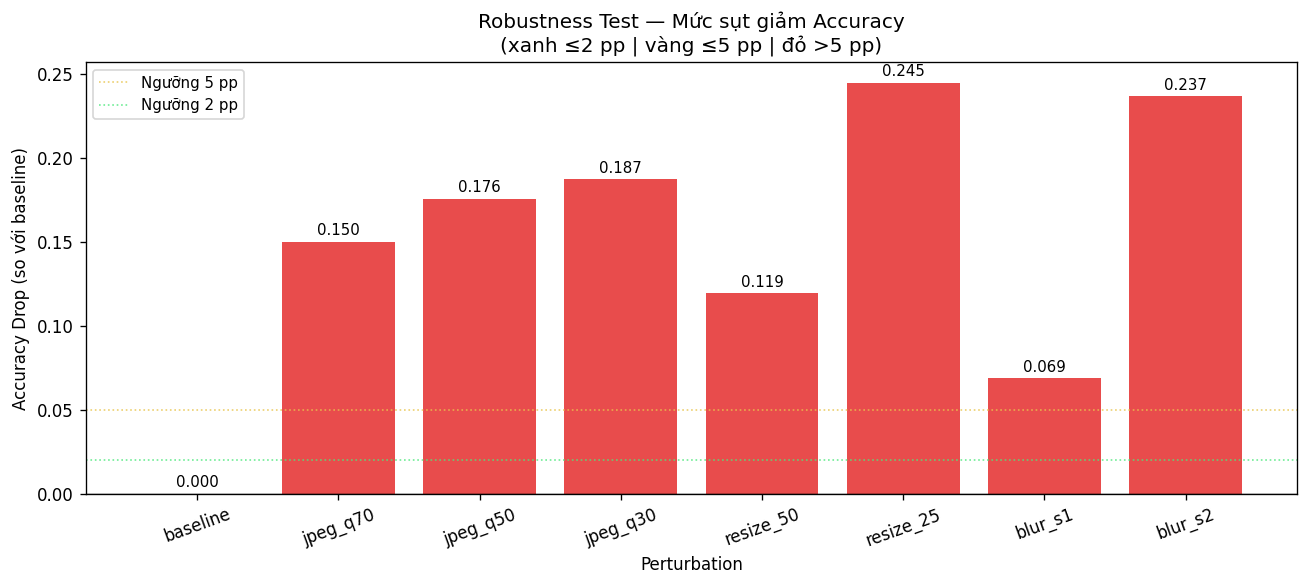

Saved robustness_drop.png

✓ Đã lưu tất cả kết quả vào: /kaggle/working/robustness

Danh sách file:
  robustness_accuracy.png
  robustness_auc.png
  robustness_drop.png
  robustness_metrics.json


In [12]:
# Biểu đồ 3: Bar chart Accuracy Drop
acc_drops = [base_acc - v for v in acc_vals]
colors    = ["#4CE87C" if d <= 0.02 else "#E8C44C" if d <= 0.05 else "#E84C4C"
             for d in acc_drops]
fig, ax   = plt.subplots(figsize=(11, 5))
bars = ax.bar(names, acc_drops, color=colors)
ax.axhline(0,    color="black",   linewidth=0.8)
ax.axhline(0.05, color="#E8C44C", linestyle=":", linewidth=1, alpha=0.8, label="Ngưỡng 5 pp")
ax.axhline(0.02, color="#4CE87C", linestyle=":", linewidth=1, alpha=0.8, label="Ngưỡng 2 pp")
ax.set_xlabel("Perturbation")
ax.set_ylabel("Accuracy Drop (so với baseline)")
ax.set_title("Robustness Test — Mức sụt giảm Accuracy\n(xanh ≤2 pp | vàng ≤5 pp | đỏ >5 pp)")
ax.tick_params(axis="x", rotation=20)
ax.legend(fontsize=9)
for bar, v in zip(bars, acc_drops):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{v:.3f}", ha="center", va="bottom", fontsize=9)
fig.tight_layout()
_save_and_show(fig, f"{OUTPUT_DIR}/robustness_drop.png")
print("Saved robustness_drop.png")

print(f"\n✓ Đã lưu tất cả kết quả vào: {OUTPUT_DIR}")
print("\nDanh sách file:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f"  {f}")

### Nhận xét — Biểu đồ 3: Mức sụt giảm Accuracy

- **Tất cả 8 perturbation đều đỏ (>5 pp)** — không có trường hợp nào đạt ngưỡng chấp nhận được (xanh ≤2 pp hoặc vàng ≤5 pp)
- Khoảng cách giữa perturbation nhẹ nhất (Blur σ=1, Drop 0.069) và nặng nhất (Resize 25%, Drop 0.245) lên tới 17.6 pp — biên độ nhạy cảm rất rộng
- **Resize 25%** và **Blur σ=2.0** là 2 điểm cực đoan nhất, cần ưu tiên đưa vào augmentation khi retrain

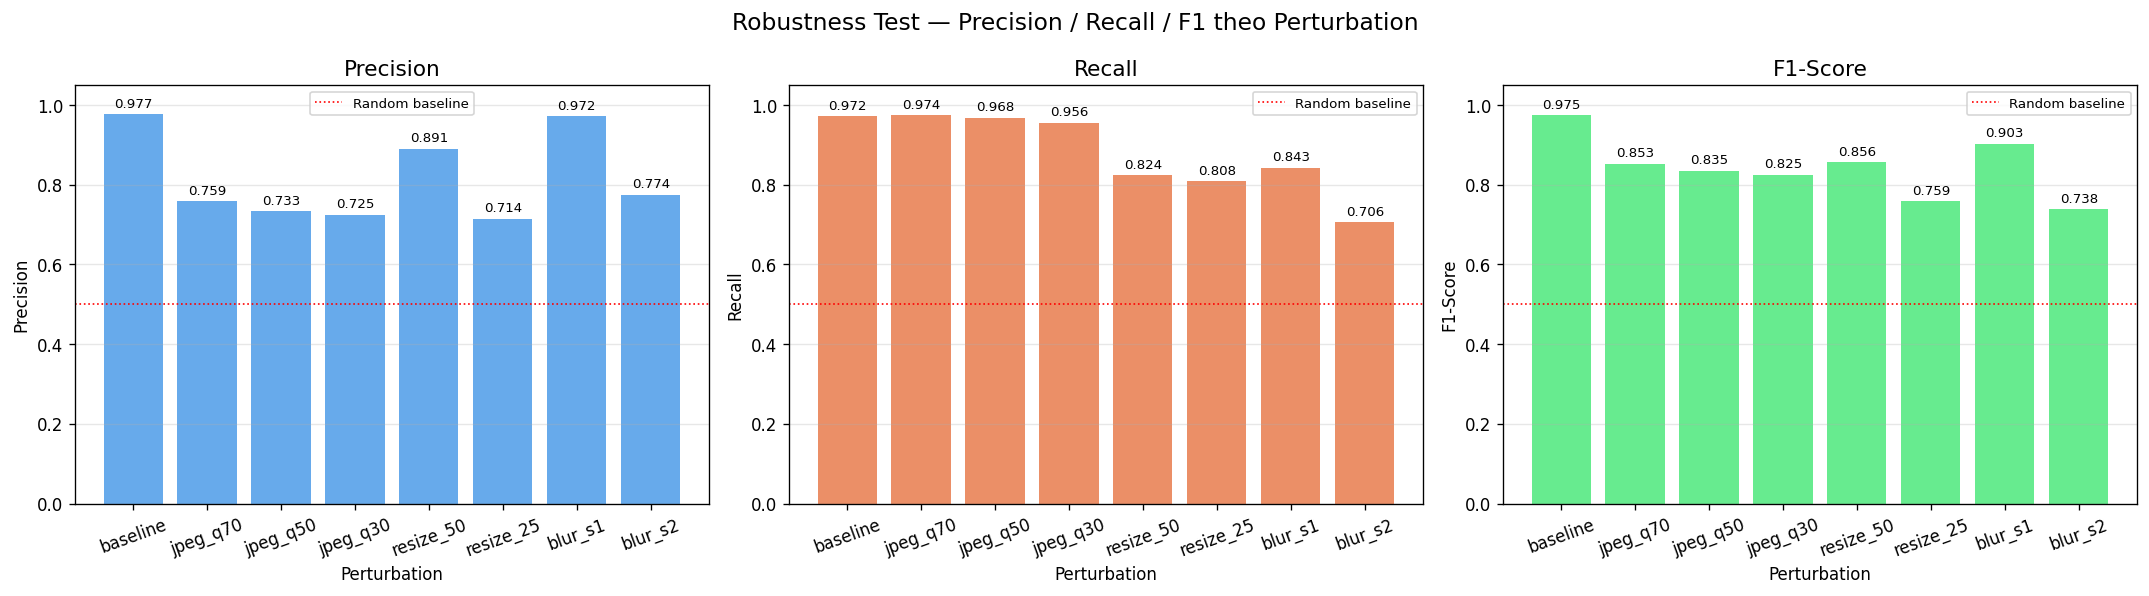

Saved robustness_prf.png


In [13]:
# Biểu đồ 4: Grouped bar chart — Precision / Recall / F1
metric_data = [
    ("Precision", prec_vals, "#4C9BE8"),
    ("Recall",    rec_vals,  "#E87C4C"),
    ("F1-Score",  f1_vals,   "#4CE87C"),
]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, vals, color) in zip(axes, metric_data):
    bars = ax.bar(names, vals, color=color, alpha=0.85)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color="red", linestyle=":", linewidth=1, label="Random baseline")
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Perturbation")
    ax.set_ylabel(title)
    ax.tick_params(axis="x", rotation=20)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)
fig.suptitle("Robustness Test — Precision / Recall / F1 theo Perturbation", fontsize=14)
fig.tight_layout()
_save_and_show(fig, f"{OUTPUT_DIR}/robustness_prf.png")
print("Saved robustness_prf.png")


### Nhận xét — Biểu đồ 4: Precision / Recall / F1

- **Recall** thường sụt giảm mạnh hơn Precision dưới blur/resize — mô hình bỏ sót ảnh Real nhiều hơn khi chất lượng suy giảm (thiên về predict Fake khi artifact bị xóa mờ)
- **JPEG compression** ảnh hưởng đồng đều Precision và Recall — nén xóa artifact high-frequency khiến mô hình không chắc chắn cả hai chiều
- **F1 phản ánh trung thực nhất**: perturbation nào F1 thấp nhất chính là điểm yếu cần ưu tiên trong augmentation khi retrain
- So sánh với Cross-Generator: ciplab cũng có Recall thấp → cùng root cause (mô hình quá nhạy cảm với texture artifact, dễ bỏ sót Real khi artifact bị xóa)


## Kết luận và hướng cải thiện

### Tóm tắt

- **Điểm mạnh:** Trên ảnh sạch (baseline), mô hình đạt Accuracy=0.9733, AUC=0.9970 — xuất sắc.
- **Điểm yếu cốt lõi:** Nhạy cảm với **mọi** dạng suy giảm chất lượng. Trong thực tế, hầu hết ảnh đều trải qua ít nhất một lần nén JPEG khi chia sẻ qua mạng xã hội hoặc ứng dụng nhắn tin — hiệu suất thực sẽ thấp hơn con số 97.33% đáng kể.
- **Worst case:** Resize 25% (Drop −24.5 pp) và Blur σ=2.0 (Drop −23.7 pp).

### Hướng cải thiện — augmentation trong train

| Vấn đề | Augmentation đề xuất |
|--------|---------------------|
| JPEG sensitivity | `albumentations.ImageCompression(quality_lower=40, quality_upper=95)` |
| Resize sensitivity | `albumentations.Downscale(scale_min=0.25, scale_max=0.75)` |
| Blur sensitivity | `albumentations.GaussianBlur(blur_limit=(3, 7))` |
| Kết hợp | Áp dụng ngẫu nhiên 1 trong 3 với xác suất 50% mỗi batch |

Chỉ cần retrain từ Stage 2 hoặc Stage 3 với transform mới — không cần thay đổi kiến trúc.

## Tải kết quả về máy

In [14]:
# ── Nén output để tải về ──────────────────────────────
import shutil
shutil.make_archive("/kaggle/working/robustness_results", "zip",
                    "/kaggle/working/robustness")
print("✓ Đã tạo: /kaggle/working/robustness_results.zip")
print("  → Vào tab Output bên phải → Download file .zip")


✓ Đã tạo: /kaggle/working/robustness_results.zip
  → Vào tab Output bên phải → Download file .zip
